# Import libraries

In [58]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from darts import TimeSeries
from darts.utils.statistics import plot_pacf, check_seasonality
from darts.models import NaiveSeasonal, NaiveDrift, XGBModel, ExponentialSmoothing, ARIMA, AutoARIMA, Prophet, RNNModel
from darts.utils.utils import ModelMode, SeasonalityMode
from sklearn.linear_model import LinearRegression
from darts.metrics import mape
from scipy import stats
from darts import concatenate


plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
def eval_forecast(model, val, forecast):
    mape_ = mape(val, forecast)
    print(f'Model {model} obtains MAPE: {round(mape_, 2)}%.')

    return mape_

def fit_eval_model(model, series, train, val):
    model.fit(train)
    forecast = model.predict(len(val))

    series.plot(label='Actual')
    forecast.plot(label='Forecast', color='red')
    plt.legend()
    plt.show()

    eval_forecast(model, val, forecast)

### Data loading

In [3]:
df = pd.read_csv("train.csv")
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


Converting a `date` column to `datetime` format and setting it as an index for a dataframe.

In [4]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace = True)

In [5]:
df.head(10)

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


### Exploratory data analysis
Are the dynamics different for each item in stores?

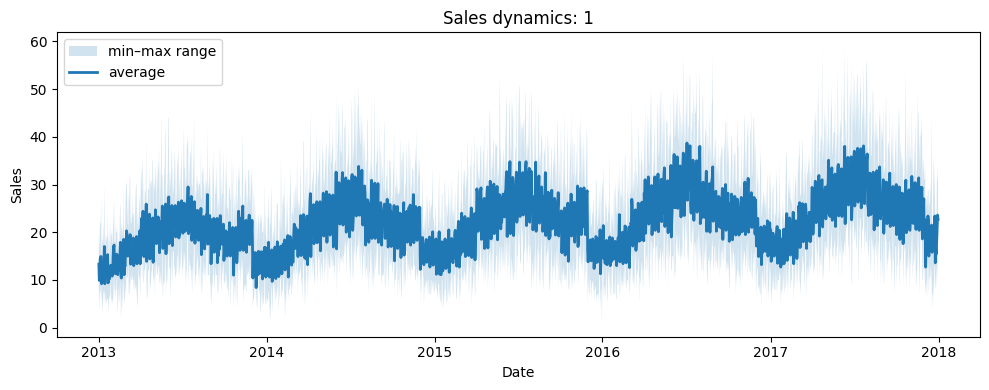

In [7]:
item_name = 1

one_item = df[df["item"] == item_name].groupby("date")["sales"]
 
mean = one_item.mean()
lower = one_item.min()
high = one_item.max()
 
plt.figure(figsize=(10, 4))
plt.fill_between(mean.index, lower, high, alpha=0.2, label="min–max range")
plt.plot(mean.index, mean, lw=2, label="average")
plt.title(f"Sales dynamics: {item_name}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

Similar seasonality is observed in all stores with peaks in summer and declines in winter. At the same time, the range of minimum - maximum values ​​is quite wide, which indicates differences between stores with a general trend for all.

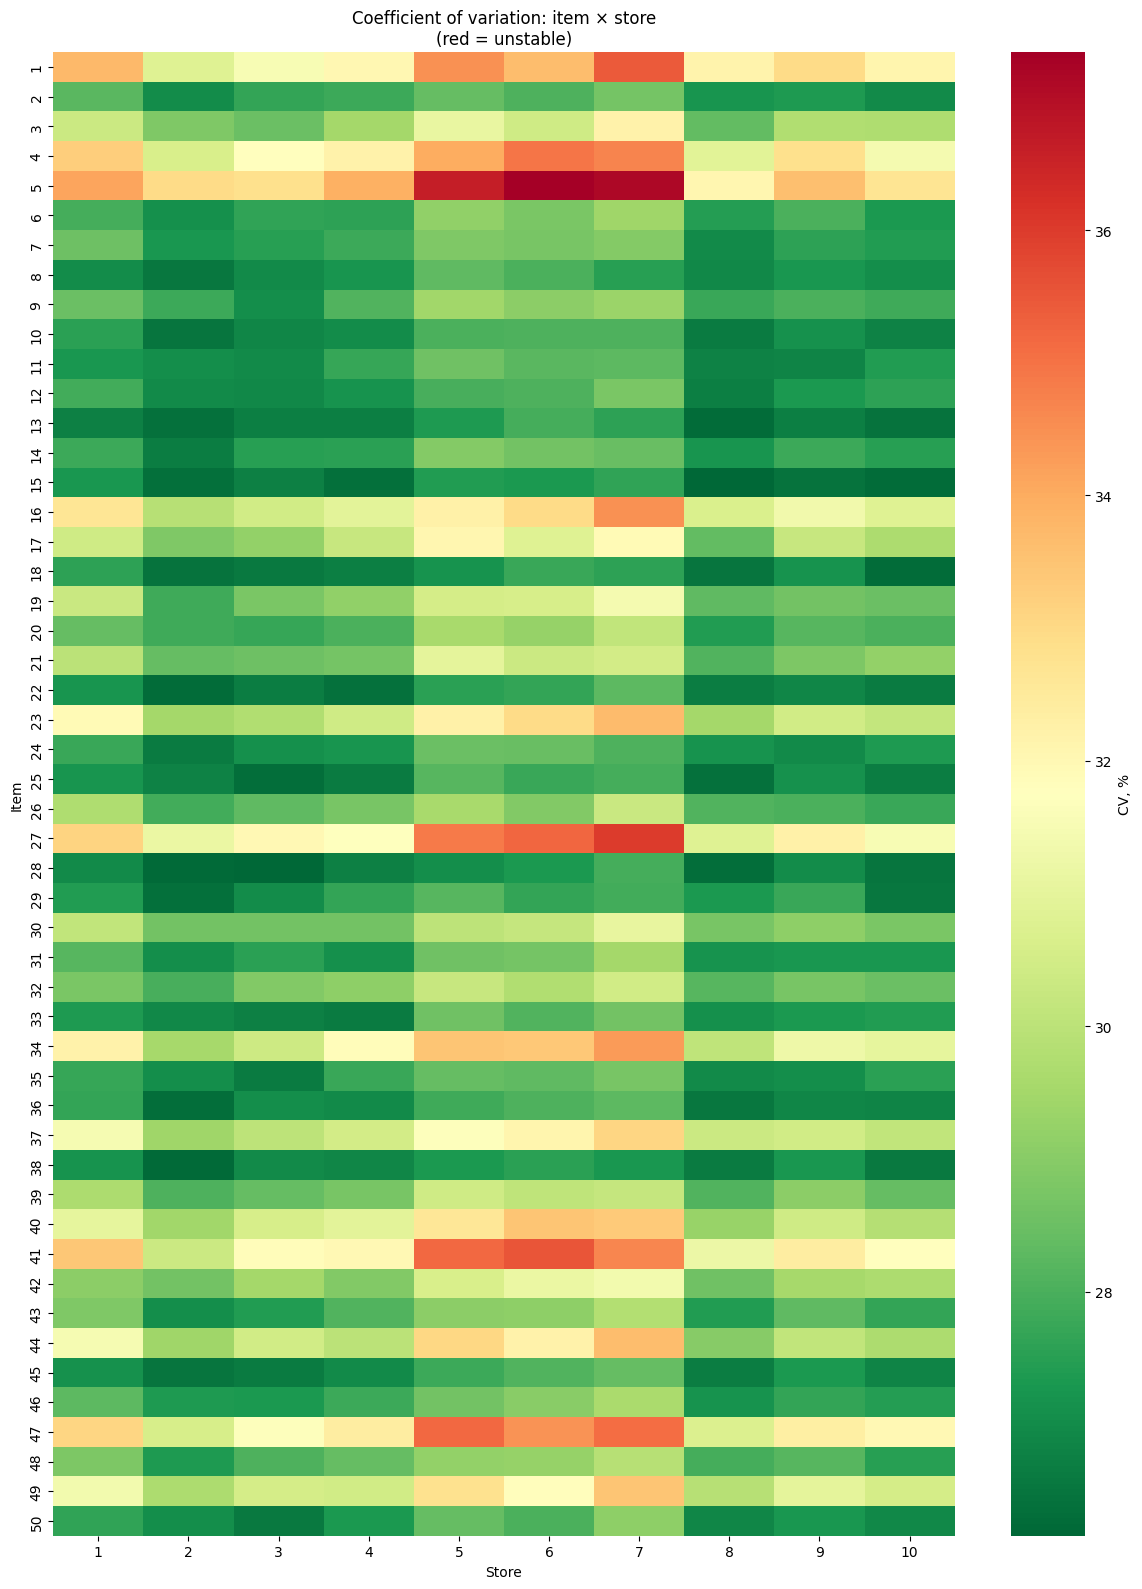

In [8]:
cv = (
    df.groupby(["item", "store"])["sales"]
    .agg(lambda x: x.std() / x.mean() * 100)
    .reset_index()
    .rename(columns={"sales": "cv"})
    .pivot(index="item", columns="store", values="cv")
)
 
plt.figure(figsize=(12, 16))
sns.heatmap(cv, cmap="RdYlGn_r", cbar_kws={"label": "CV, %"})
plt.title("Coefficient of variation: item × store\n(red = unstable)")
plt.xlabel("Store")
plt.ylabel("Item")
plt.tight_layout()
plt.show()

Stores 5, 6, 7 are more unstable compared to the others, as indicated by the coefficient of variation, especially in the case of products 1, 4, 5, 16, 27, 41 and 47.

Products 6-15 are characterized by stability in all stores.

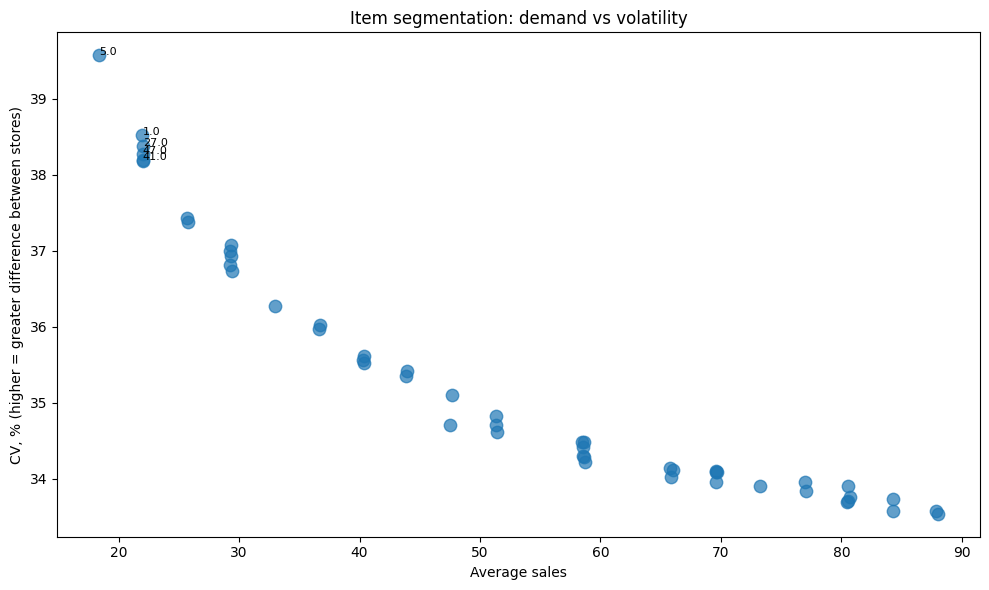

In [9]:
item_stats = (
    df.groupby("item")["sales"]
    .agg(
        mean_sales="mean",
        cv=lambda x: x.std() / x.mean() * 100
    )
    .reset_index()
)
 
plt.figure(figsize=(10, 6))
plt.scatter(item_stats["mean_sales"], item_stats["cv"], alpha=0.7, s=80)
 
# підписуємо топ-5 нестабільних
top5 = item_stats.nlargest(5, "cv")
for _, row in top5.iterrows():
    plt.annotate(row["item"], (row["mean_sales"], row["cv"]), fontsize=8)
 
plt.title("Item segmentation: demand vs volatility")
plt.xlabel("Average sales")
plt.ylabel("CV, % (higher = greater difference between stores)")
plt.tight_layout()
plt.show()
 

Product 5 is the most volatile with the lowest sales, making its sales difficult to predict.

There is an inverse relationship, the higher the average sales of a product, the less volatile it is.

### Single time series analysis

A subset of data corresponding to sales of the product with `item == 1` in the store with `store == 1` was selected.

This row was decomposed using an additive model into trend, seasonality, and residuals with the `statsmodels` library.

In [10]:
df_1 = df[(df['item'] == 1) & (df['store'] == 1)]
df_1.head()

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10


In [11]:
print("Unique store: ", df_1['store'].unique())
print("Unique item: ", df_1['item'].unique())

Unique store:  [1]
Unique item:  [1]


In [12]:
fig = px.line(df_1, y = 'sales')

fig.update_layout(template="simple_white",
                  title_text='Dynamics of sales item 1 in store 1')


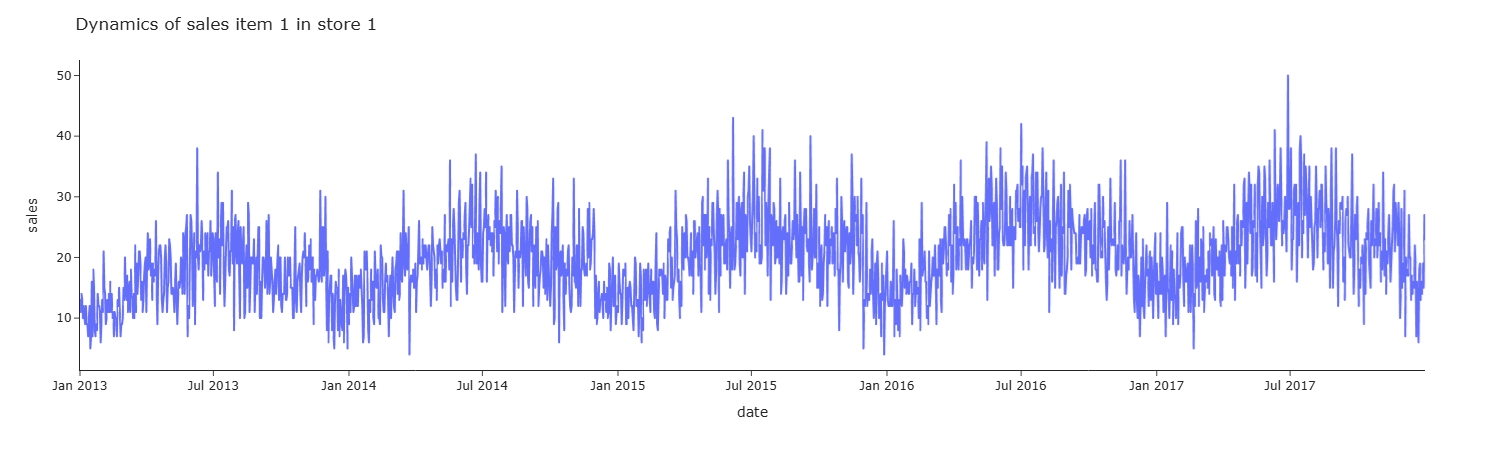

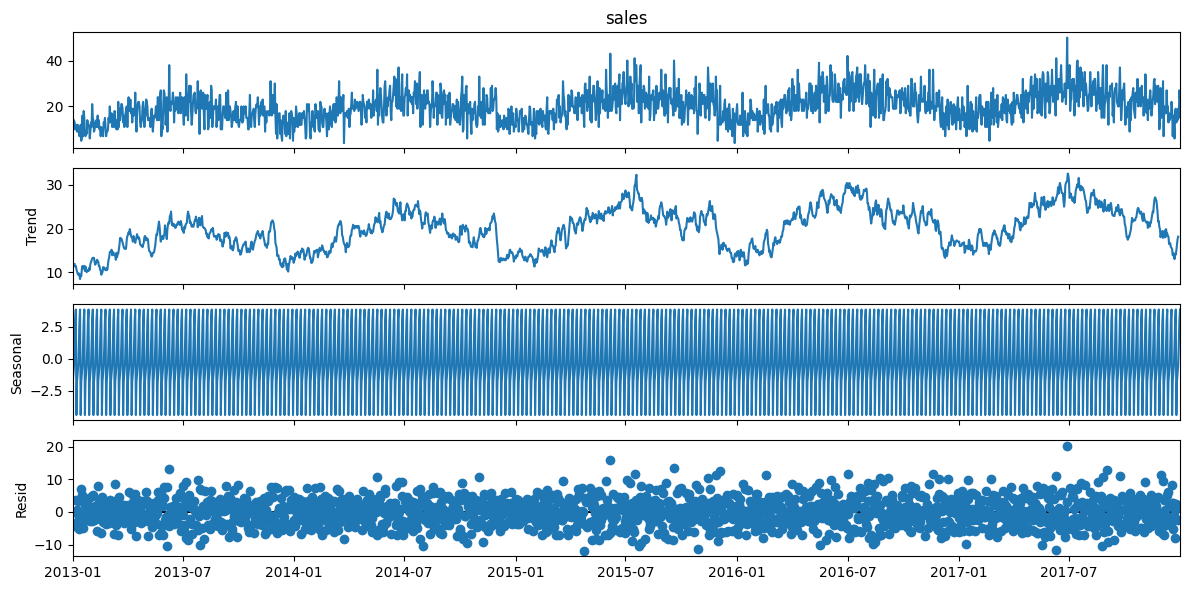

In [13]:
decomposition_plot_add = seasonal_decompose(df_1['sales'], model = 'additive')
decomposition_plot_add.plot()
plt.show();

According to the decomposition, there is a certain seasonality, which is difficult to accurately detect on a large scale, but most likely weekly.

At the same time, we have an increasing trend, which also reflects annual seasonality.

As for the residuals, although they do not have certain patterns indicating heteroskedasticity, nevertheless, at the moment the standard deviation is quite significant ([-10; 10]) for current sales.

### Creating a `TimeSeries` class object in `darts` for the `sales` column only.

In [14]:
series = TimeSeries.from_dataframe(df_1, value_cols = 'sales')

In [15]:
series

,sales
date,
2013-01-01,13.0
2013-01-02,11.0
2013-01-03,14.0
2013-01-04,13.0
2013-01-05,10.0
...,...
2017-12-27,14.0
2017-12-28,19.0
2017-12-29,15.0


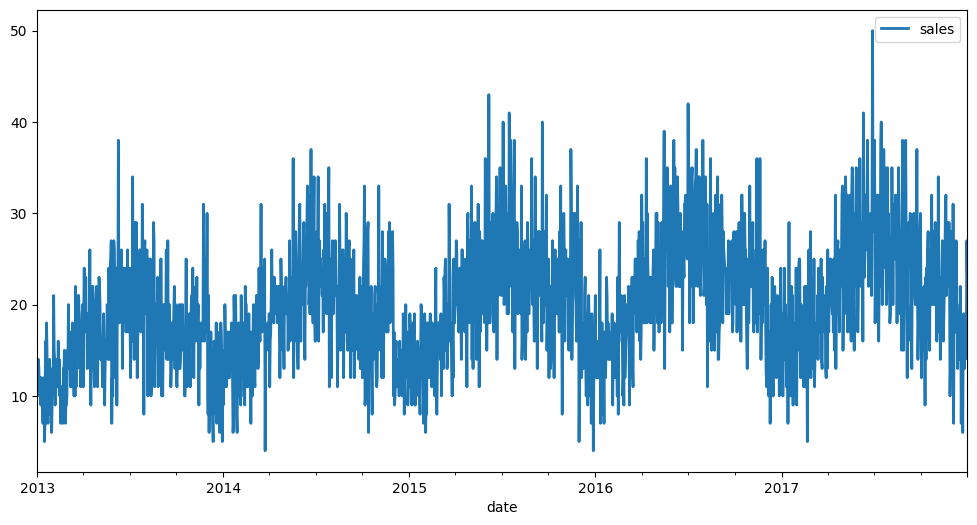

In [16]:
series.plot();

### Splitting data into training and validation samples

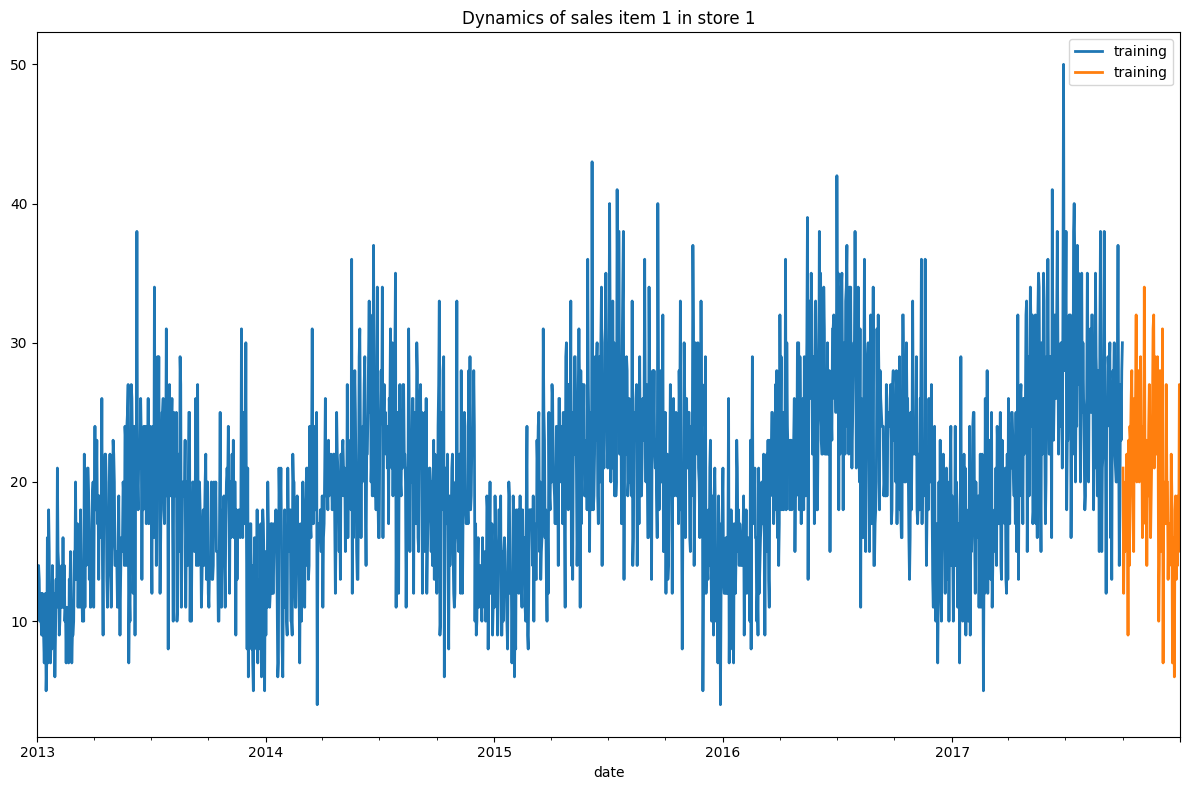

In [17]:
train, val = series.split_before(pd.Timestamp("2017-10-01"))
train.plot(label = "training", figsize = (12,8))
val.plot(label = "training", figsize = (12,8))
plt.title('Dynamics of sales item 1 in store 1')
plt.tight_layout()
plt.show();

### Construction of the partial autocorrelation function

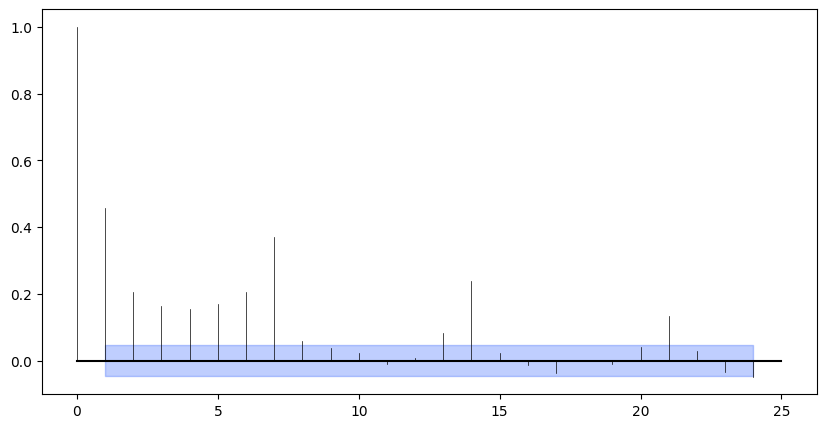

In [18]:
plot_pacf(train, alpha = 0.05)

According to partial autocorrelation, lags 1, 7, and to a lesser extent 14 and 21, are important for forecasting.

### Seasonality check

In [19]:
for m in range(2, 25):
    is_seasonal, period = check_seasonality(train, m = m, alpha = 0.05)
    if is_seasonal:
        print(f"There is seasonality of order {period}.")

There is seasonality of order 7.
There is seasonality of order 14.
There is seasonality of order 21.


### Building a naive model NaiveSeasonal + NaieDrift for data forecasting

#### Basic version

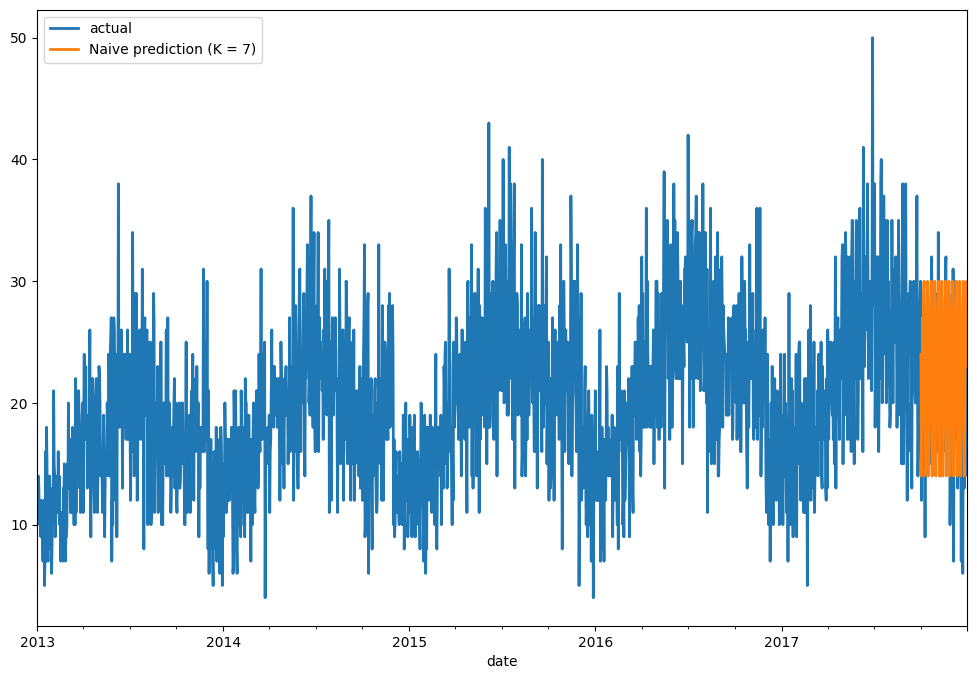

In [20]:
seasonal_model = NaiveSeasonal(K = 7)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(len(val))

series.plot(label = "actual", figsize = (12,8))
seasonal_forecast.plot(label = "Naive prediction (K = 7)", figsize = (12,8));

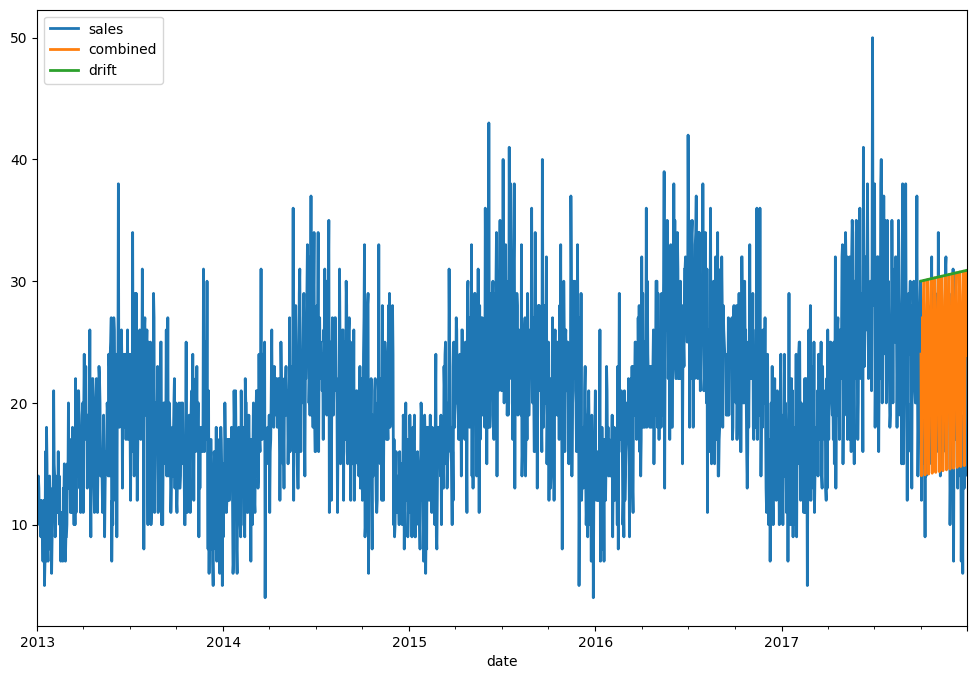

In [21]:
drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(len(val))

combined_forecast = drift_forecast + seasonal_forecast - train.last_value()

series.plot()
combined_forecast.plot(label = "combined", figsize = (12,8))
drift_forecast.plot(label = "drift", figsize = (12,8));

According to the simulation results, we can see that both NaiveSeasonal and NaiveDrift do not work well with seasonality, although they partially capture the trend.

#### Taking into account two seasonal components

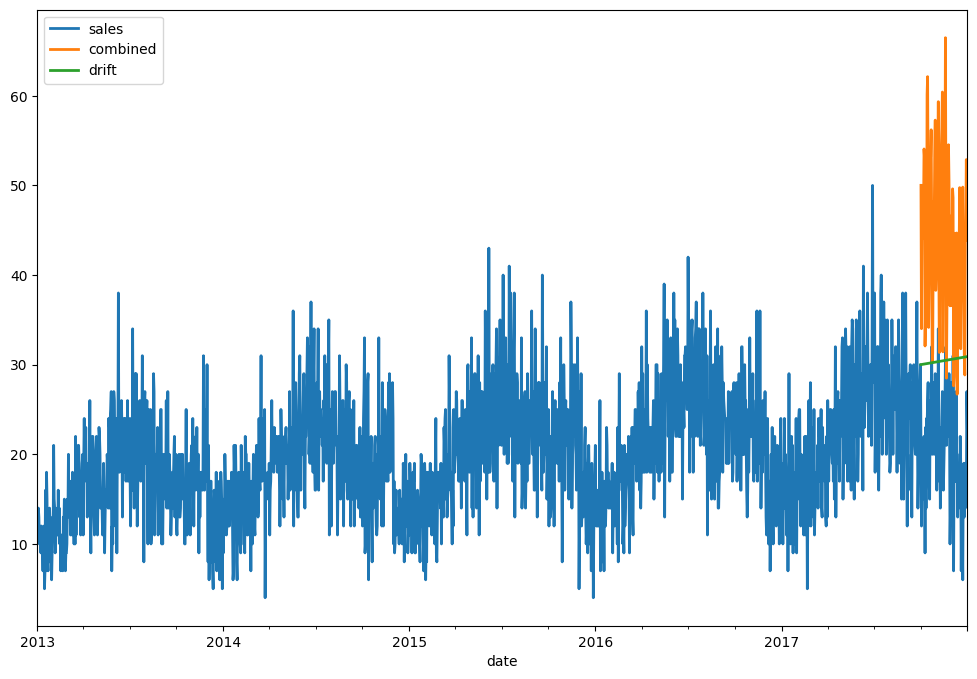

In [22]:
seasonal_model_year = NaiveSeasonal(K = 364)
seasonal_model_year.fit(train)
seasonal_forecast_year = seasonal_model_year.predict(len(val))

combined_forecast_wy = drift_forecast + seasonal_forecast + seasonal_forecast_year - train.last_value()

series.plot()
combined_forecast_wy.plot(label = "combined", figsize = (12,8))
drift_forecast.plot(label = "drift", figsize = (12,8));

After taking into account two seasonal components (weekly and annual), it was possible to better take into account seasonality, but the trend component was poorly taken into account.

#### Including weights for components

In [23]:
X = np.column_stack([
    seasonal_forecast.values(),
    seasonal_forecast_year.values(),
    drift_forecast.values()
])

y_true = val.values().flatten()

model = LinearRegression(fit_intercept=False)
model.fit(X, y_true)

weights = model.coef_
print(weights)

[0.23926298 0.33740623 0.2569968 ]


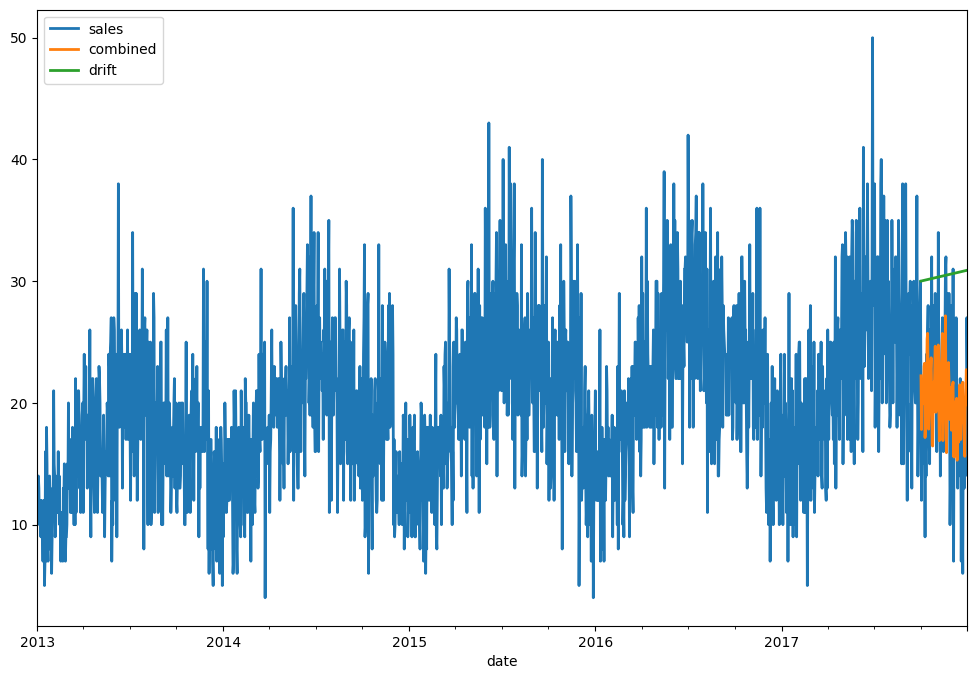

In [24]:
combined_wy_reg = (
    weights[0] * seasonal_forecast.values() +
    weights[1] * seasonal_forecast_year.values() +
    weights[2] * drift_forecast.values()
)

combined_wy_reg = TimeSeries.from_times_and_values(
    seasonal_forecast.time_index,
    combined_wy_reg
)

series.plot()
combined_wy_reg.plot(label = "combined", figsize = (12,8))
drift_forecast.plot(label = "drift", figsize = (12,8));

By selecting coefficients for a model with seasonal components, we were able to better take into account the trend and seasonality, but the scale of sales was somewhat incompletely taken into account.

In [25]:
print(f"MAPE Naive Seasonal: {round(mape(val, seasonal_forecast), 2)}%.")
print(f"MAPE Naive Seasonal & Drift: {round(mape(val, combined_forecast), 2)}%.")

print(f"MAPE Naive Seasonal & Drift with two seasonal components: {round(mape(val, combined_forecast_wy), 2)}%.")
print(f"MAPE Naive Seasonal & Drift with two weighted seasonal components: {round(mape(val, combined_wy_reg), 2)}%.")

MAPE Naive Seasonal: 38.17%.
MAPE Naive Seasonal & Drift: 39.91%.
MAPE Naive Seasonal & Drift with two seasonal components: 136.71%.
MAPE Naive Seasonal & Drift with two weighted seasonal components: 26.28%.


The conclusions drawn in the previous paragraph are also confirmed by MAPE, according to which Naive Seasonal & Drift with weighted seasonal components best predicted the results.

### Building a XBGModel

#### XGBoost Base Model

In [26]:
xgb_model = XGBModel(
    lags = 14,
    output_chunk_length = 1,
    n_estimators = 300,
    max_depth = 3,
    learning_rate = 0.1,
    subsample = 0.8,
    colsample_bytree = 0.8
)

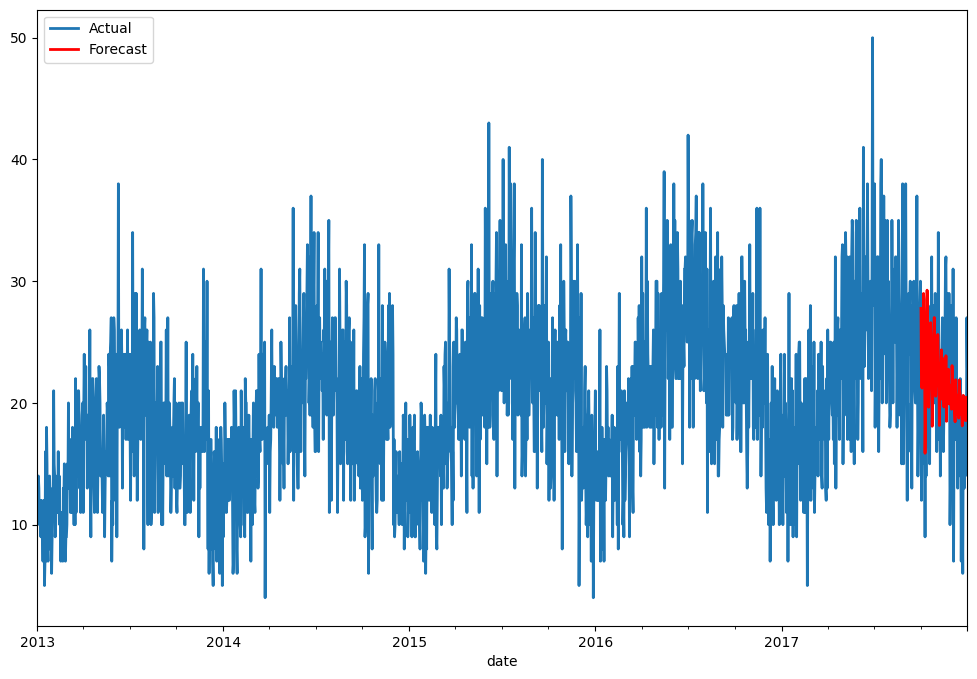

Model XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...) obtains MAPE: 28.82%.


In [27]:
xgb_model.fit(train)

forecast = xgb_model.predict(len(val))
series.plot(label='Actual', figsize = (12,8))
forecast.plot(label='Forecast', color='red', figsize = (12,8))
plt.legend()
plt.show()

eval_forecast(xgb_model, val, forecast);

The considered XGBoost model, although it provided a fairly acceptable error (28.82%), compared to previous results, nevertheless, visually assessing it, we can see that neither seasonality nor trend were taken into account well enough.

#### Model with past covariates

In [28]:
def enrich_with_date_features(df):
  # Feature Extraction
  df["dayofweek"] = df['date'].dt.dayofweek
  df["year"] = df['date'].dt.year
  df["dayofyear"] = df['date'].dt.dayofyear
  df["sin_day"] = np.sin(df["dayofyear"])
  df["cos_day"] = np.cos(df["dayofyear"])
  df["dayofmonth"] = df['date'].dt.day
  return df

In [29]:
covariates_df = pd.concat([
    train.to_dataframe().reset_index(),
    val.to_dataframe().reset_index()
])

covariates_df = enrich_with_date_features(covariates_df)

covariates = TimeSeries.from_dataframe(covariates_df, time_col="date")

In [30]:
xgb_model = XGBModel(
    lags=14,
    lags_past_covariates = [-1, -7, -14],
    output_chunk_length=1,
    n_estimators=300,
    max_depth=3,
    learning_rate=0.1
)

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


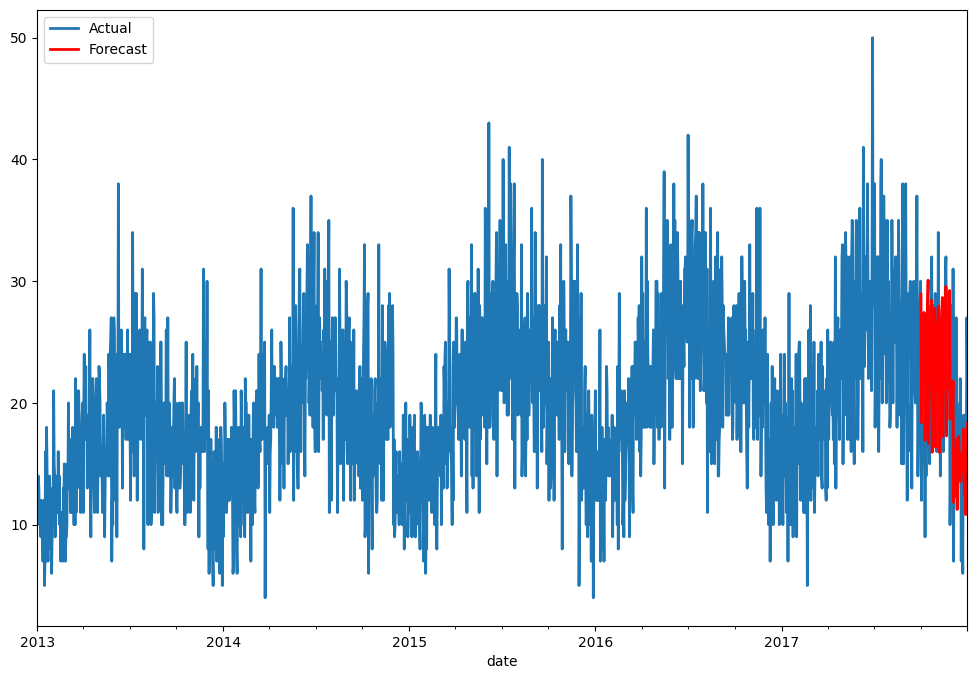

Model XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...) obtains MAPE: 24.48%.


In [31]:
xgb_model.fit(train, past_covariates=covariates)

forecast = xgb_model.predict(len(val), past_covariates=covariates)
series.plot(label='Actual', figsize = (12,8))
forecast.plot(label='Forecast', color='red', figsize = (12,8))
plt.legend()
plt.show()

eval_forecast(xgb_model, val, forecast);

After adding past covariates, the XGBoost model provided a much better result compared to previous models. Moreover, even from the described dynamics, we can note that the model took into account the peculiarities of the time series components much better.

### Building a ExponentialSmoothing model

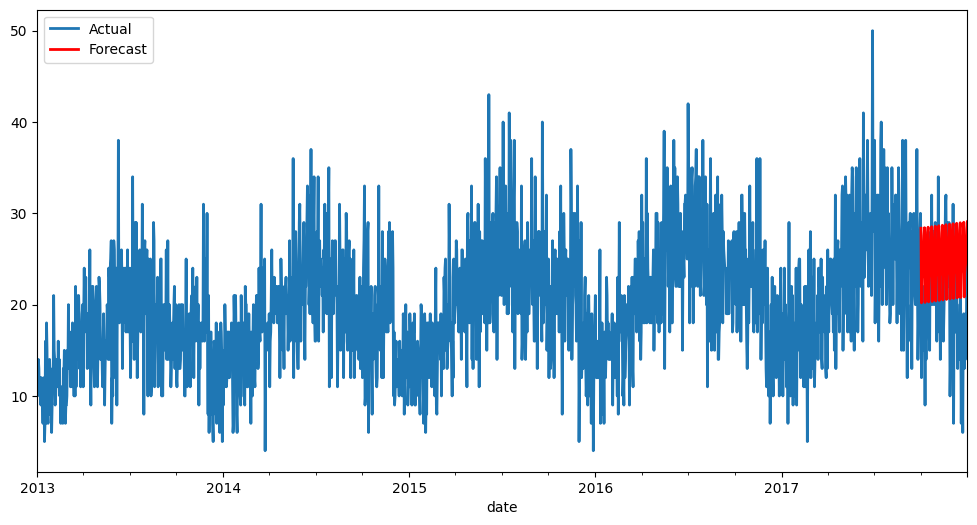

Model ExponentialSmoothing() obtains MAPE: 39.01%.


In [32]:
fit_eval_model(ExponentialSmoothing(), series, train, val)

The base ExponentialSmoothing model has so far provided the largest error, not taking seasonality into account at all.

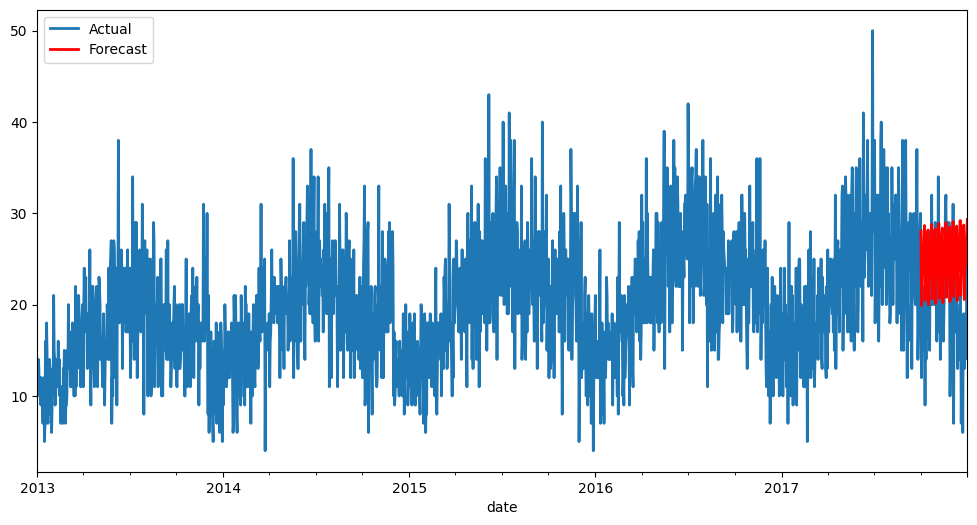

Model ExponentialSmoothing(seasonal_periods=14) obtains MAPE: 39.0%.


In [33]:
expon_model = ExponentialSmoothing(
    trend = ModelMode.ADDITIVE,
    seasonal = SeasonalityMode.ADDITIVE,
    seasonal_periods = 14
)

fit_eval_model(expon_model, series, train, val)

By adding additional parameters to the model, we managed to reduce the error by only 0.01 percentage points, which is still the worst result so far.

### Building a ARIMA model

#### ARIMA

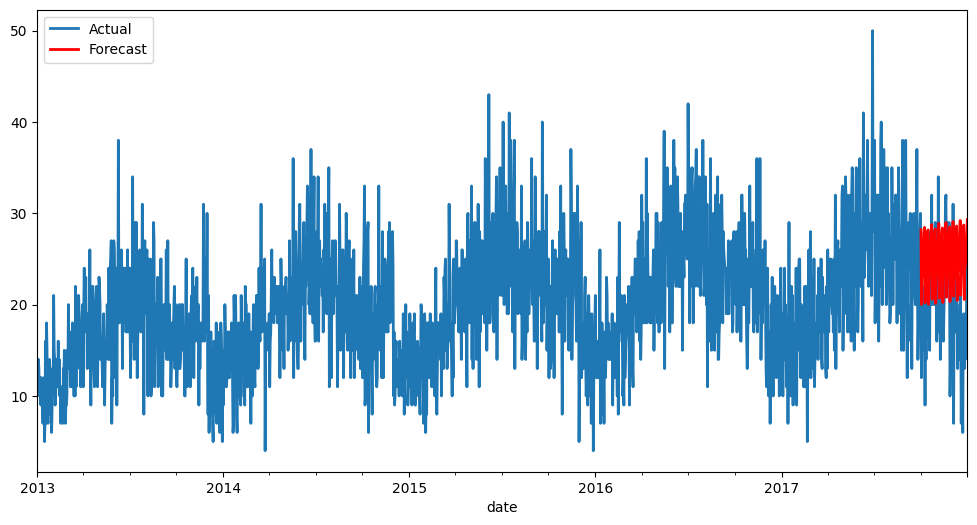

Model ARIMA(p=1, q=1, seasonal_order=(1, 1, 1, 14)) obtains MAPE: 39.03%.


In [34]:
arima_model = ARIMA(p = 1, d = 1, q = 1, seasonal_order=(1, 1, 1, 14))
fit_eval_model(arima_model, series, train, val)

The ARIMA(p=1, q=1, seasonal_order=(1, 1, 1, 14)) model, like Exponential Smoothing, provided a rather inaccurate forecast with a similar error rate of 39.03%. Like the previous model, the current one almost did not take into account seasonality.

#### SARIMAX

In [35]:
def make_covariates(df):
    df = df.copy()

    df["dayofweek"] = df["date"].dt.dayofweek
    df["dayofyear"] = df["date"].dt.dayofyear

    for i in range(7):
        df[f"wd_{i}"] = (df["dayofweek"] == i).astype(int)

    df["sin_year"] = np.sin(2 * np.pi * df["dayofyear"] / 365)
    df["cos_year"] = np.cos(2 * np.pi * df["dayofyear"] / 365)

    return df

In [ ]:
col_covs = ["dayofweek", "dayofyear", "wd_0", "wd_1", "wd_2", "wd_3", "wd_4", "wd_5", "wd_6", "sin_year", "cos_year"]

train_df = train.to_dataframe().reset_index()
train_cov = TimeSeries.from_dataframe(
    make_covariates(train_df)[["date"] + col_covs], 
    time_col="date"
)

val_dates_df = pd.DataFrame({"date": pd.date_range(
    start=val.start_time(),
    end=val.end_time(),
    freq=val.freq_str
)})
future_cov = TimeSeries.from_dataframe(
    make_covariates(val_dates_df)[["date"] + col_covs],
    time_col="date"
)

full_cov = train_cov.append(future_cov)

sarimax_model = ARIMA(1, 1, 1, seasonal_order=(1, 1, 1, 14))
sarimax_model.fit(train, future_covariates=full_cov)

c:\Users\ADMIN\ml_projects_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(p=1, d=1, q=1, seasonal_order=(1, 1, 1, 14), trend=None, random_state=None, add_encoders=None)

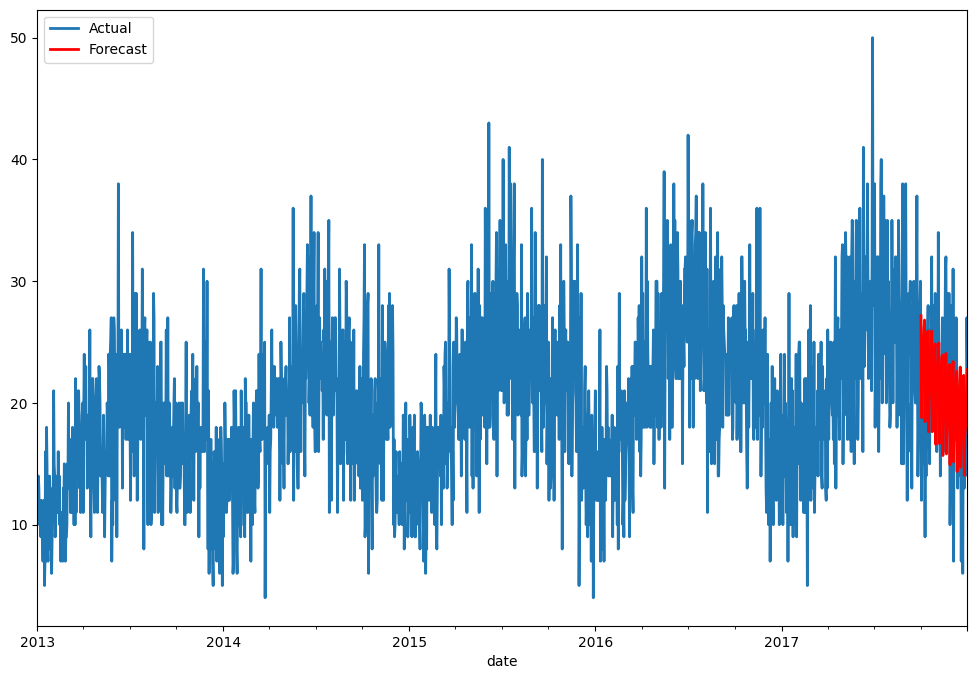

Model ARIMA(p=1, q=1, seasonal_order=(1, 1, 1, 14)) obtains MAPE: 25.3%.


np.float64(25.30101107455891)

In [37]:
sarimax_forecast = sarimax_model.predict(len(val), future_covariates=full_cov)
series.plot(label='Actual', figsize = (12,8))
sarimax_forecast.plot(label='Forecast', color='red', figsize = (12,8))
plt.legend()
plt.show()

eval_forecast(sarimax_model, val, sarimax_forecast)

The ARIMA model constructed taking into account seasonal components gave a fairly good result with an error rate of 25.3%. However, we can see that seasonality in the middle of the validation period was not fully taken into account.

### Finding optimal ARIMA model parameters using the AutoARIMA model

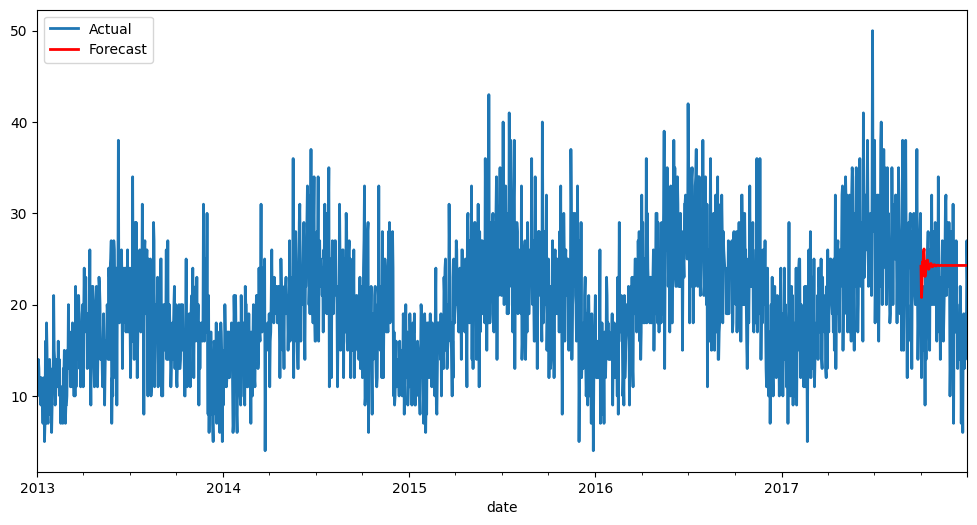

Model AutoARIMA(start_p=7, max_p=21, start_q=1) obtains MAPE: 39.49%.


In [38]:
auto_arima_model = AutoARIMA(start_p = 7, max_p = 21, start_q = 1)

fit_eval_model(auto_arima_model, series, train, val)

In [40]:
m = auto_arima_model.model.model_

p, q, P, Q, s, d, D = m['arma'][0], m['arma'][1], m['arma'][2], m['arma'][3], m['arma'][4], m['arma'][5], m['arma'][6]

coefs = list(m['coef'].values())
names = list(m['coef'].keys())
std_errors = np.sqrt(np.diag(m['var_coef']))
t_stats = coefs / std_errors
p_values = 2 * (1 - stats.norm.cdf(np.abs(t_stats)))

print("=" * 60)
print("AutoARIMA Summary")
print("=" * 60)
print(f"Order:          ({p}, {d}, {q})")
print(f"Seasonal Order: ({P}, {D}, {Q})[{s}]")
print(f"AIC:            {m['aic']:.4f}")
print(f"AICc:           {m['aicc']:.4f}")
print(f"BIC:            {m['bic']:.4f}")
print(f"Log-likelihood: {m['loglik']:.4f}")
print(f"Sigma^2:        {m['sigma2']:.4f}")
print(f"Observations:   {m['nobs']}")
print("-" * 60)
print(f"{'Coef':<12} {'Estimate':>12} {'Std Error':>12} {'t-stat':>10} {'p-value':>10}")
print("-" * 60)
for name, coef, se, t, p in zip(names, coefs, std_errors, t_stats, p_values):
    signif = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {name:<10} {float(coef):>12.6f} {float(se):>12.6f} {float(t):>10.4f} {float(p):>10.4f} {signif}")
print("=" * 60)
print("Signif: *** p<0.001  ** p<0.01  * p<0.05")

AutoARIMA Summary
Order:          (7, 1, 1)
Seasonal Order: (0, 0, 0)[1]
AIC:            10591.1199
AICc:           10591.2244
BIC:            10640.2384
Log-likelihood: -5286.5600
Sigma^2:        26.2173
Observations:   1733
------------------------------------------------------------
Coef             Estimate    Std Error     t-stat    p-value
------------------------------------------------------------
  ar1            0.029767     0.027436     1.0850     0.2779 
  ar2           -0.084568     0.026781    -3.1577     0.0016 **
  ar3           -0.081898     0.025104    -3.2623     0.0011 **
  ar4           -0.069360     0.025144    -2.7584     0.0058 **
  ar5           -0.038600     0.024412    -1.5812     0.1138 
  ar6            0.002915     0.024656     0.1182     0.9059 
  ar7            0.261356     0.022375    11.6808     0.0000 ***
  ma1           -0.903469     0.024022   -37.6108     0.0000 ***
Signif: *** p<0.001  ** p<0.01  * p<0.05


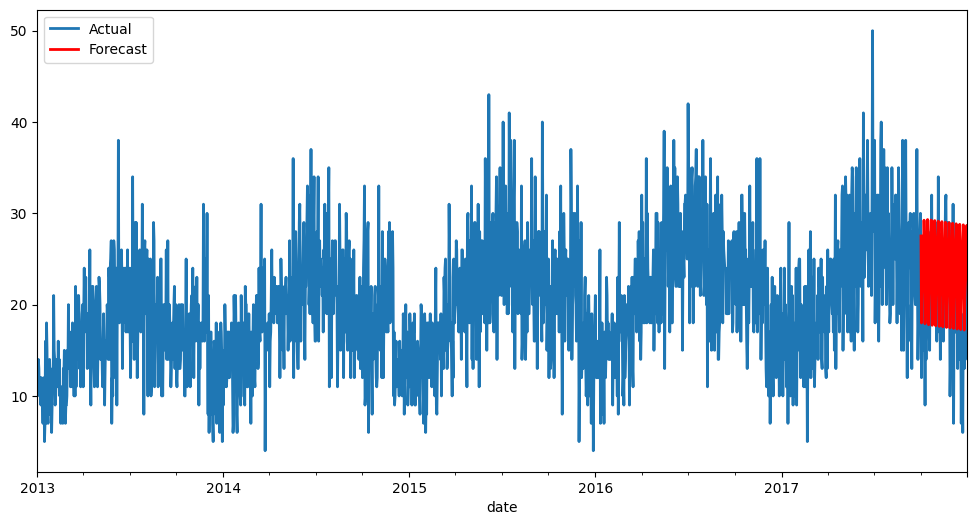

Model AutoARIMA(start_p=1, max_p=7, start_q=1, max_q=2, d=1, seasonal=True, season_length=7, start_P=1, max_P=2, start_Q=1, max_Q=2, D=1, ic=aic, stepwise=False, nmodels=150) obtains MAPE: 35.1%.


In [ ]:
auto_arima_model_season = AutoARIMA(
    start_p=1,     
    max_p=7,
    start_q=1,
    max_q=2,
    d=1,
    seasonal=True,
    season_length=7, 
    start_P=1,
    max_P=2,
    start_Q=1,
    max_Q=2,
    D=1,        
    ic='aic',
    stepwise=False,   
    nmodels=150,
)

fit_eval_model(auto_arima_model_season, series, train, val)

AutoARIMA, even with current attempts at improvement, performed poorly compared to previous models (MAPE at 35.1% and 39.49%), again, poorly accounting for seasonality.

### Building a Prophet model

17:31:28 - cmdstanpy - INFO - Chain [1] start processing
17:31:29 - cmdstanpy - INFO - Chain [1] done processing
17:31:29 - cmdstanpy - INFO - Chain [1] start processing
17:31:29 - cmdstanpy - INFO - Chain [1] done processing


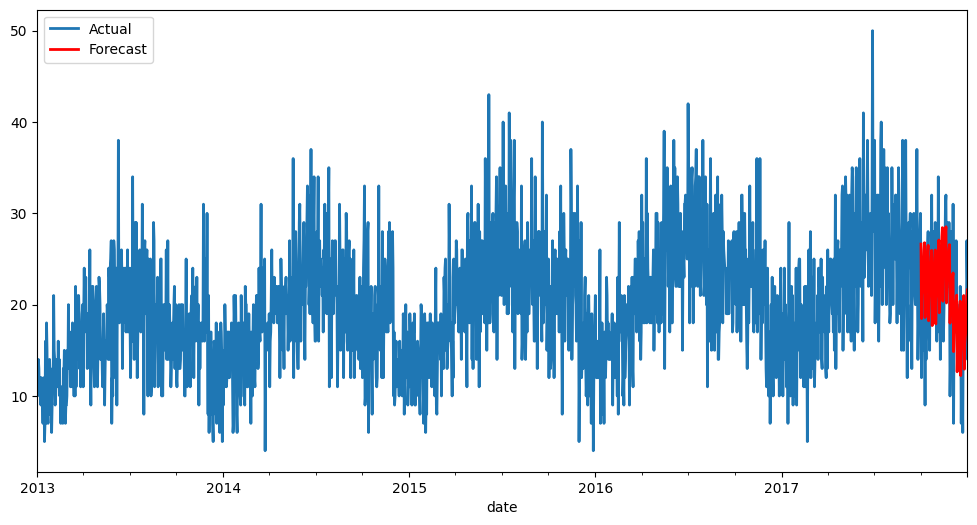

Model Prophet() obtains MAPE: 23.8%.


In [45]:
prophet_model = Prophet()
prophet_model.fit(train)

fit_eval_model(prophet_model, series, train, val)

17:37:29 - cmdstanpy - INFO - Chain [1] start processing
17:37:29 - cmdstanpy - INFO - Chain [1] done processing


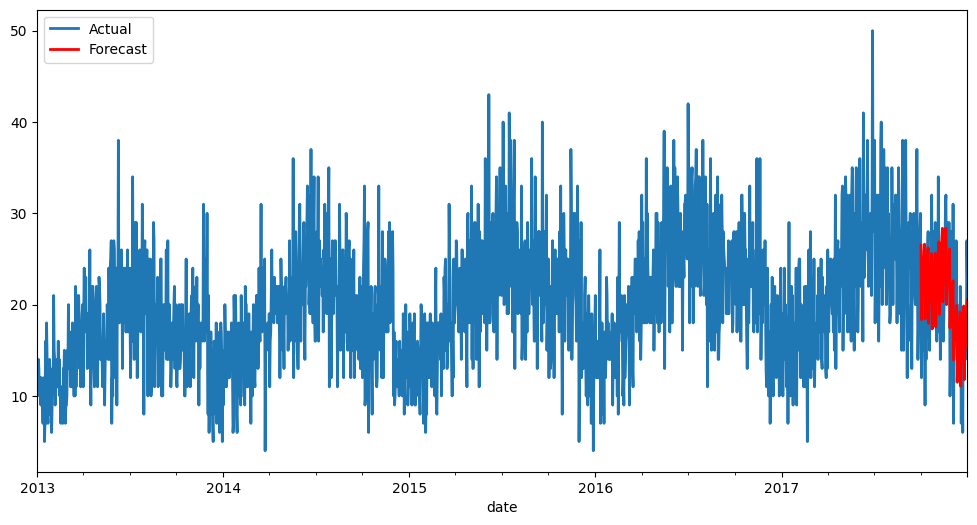

Model Prophet(seasonality_mode=multiplicative, weekly_seasonality=False, yearly_seasonality=False) obtains MAPE: 22.97%.


In [52]:
prophet_model_multi = Prophet(seasonality_mode='multiplicative', weekly_seasonality=False, yearly_seasonality=False,)
prophet_model_multi.add_seasonality('weekly', seasonal_periods= 7, fourier_order= 5, mode= 'additive')
prophet_model_multi.add_seasonality('yearly', seasonal_periods= 365.25, fourier_order= 10, mode= 'multiplicative')

fit_eval_model(prophet_model_multi, series, train, val)

The Prophet model, both with basic settings and with additional ones to take into account seasonality, has shown the best result so far, both in terms of visual assessment of forecasting results during the validation period, and the quality metric, which for the first model is at the level of 23.8% and for the second, respectively, 22.97%. The model took into account both trend and seasonality.

### Building a RNNModel model

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 2.8 K  | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
2.8 K     Trainable params
0         Non-trainable params
2.8 K     Total params
0.011     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
c:\Users\ADMIN\ml_projects_env\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

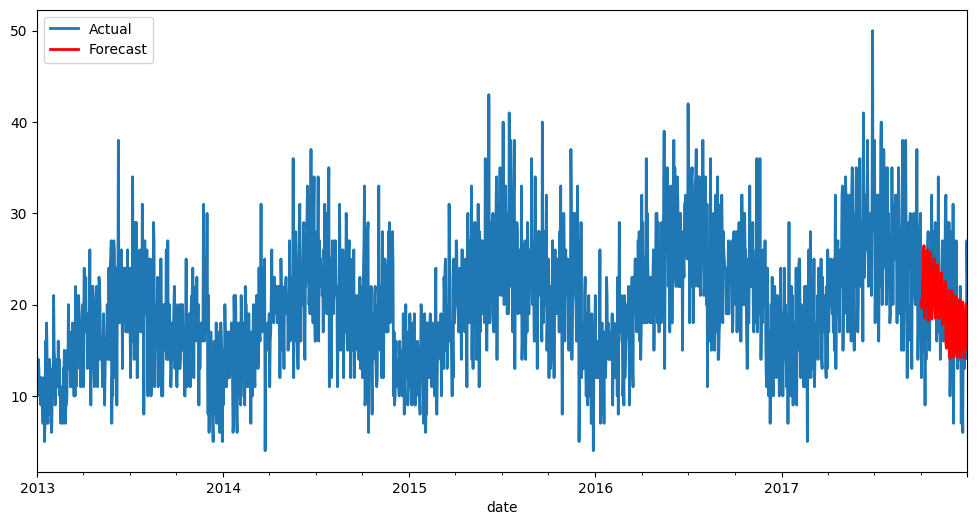

Model RNNModel(model=LSTM, input_chunk_length=7, n_epochs=300) obtains MAPE: 27.67%.


In [55]:
rnn_model = RNNModel(model = 'LSTM', input_chunk_length = 7, n_epochs = 300)

fit_eval_model(rnn_model, series, train, val)

RNNModel with LSTM gave good results with MAPE at 27.67%, which is better than previous models, but clearly inferior to Prophet. The model slightly underestimated seasonality in the middle of the validation period.

### Backtest for Prophet

18:16:55 - cmdstanpy - INFO - Chain [1] start processing
18:16:55 - cmdstanpy - INFO - Chain [1] done processing
18:16:55 - cmdstanpy - INFO - Chain [1] start processing
18:16:56 - cmdstanpy - INFO - Chain [1] done processing
18:16:56 - cmdstanpy - INFO - Chain [1] start processing
18:16:56 - cmdstanpy - INFO - Chain [1] done processing
18:16:56 - cmdstanpy - INFO - Chain [1] start processing
18:16:56 - cmdstanpy - INFO - Chain [1] done processing
18:16:56 - cmdstanpy - INFO - Chain [1] start processing
18:16:57 - cmdstanpy - INFO - Chain [1] done processing
18:16:57 - cmdstanpy - INFO - Chain [1] start processing
18:16:57 - cmdstanpy - INFO - Chain [1] done processing
18:16:57 - cmdstanpy - INFO - Chain [1] start processing
18:16:57 - cmdstanpy - INFO - Chain [1] done processing
18:16:57 - cmdstanpy - INFO - Chain [1] start processing
18:16:58 - cmdstanpy - INFO - Chain [1] done processing
18:16:58 - cmdstanpy - INFO - Chain [1] start processing
18:16:58 - cmdstanpy - INFO - Chain [1]

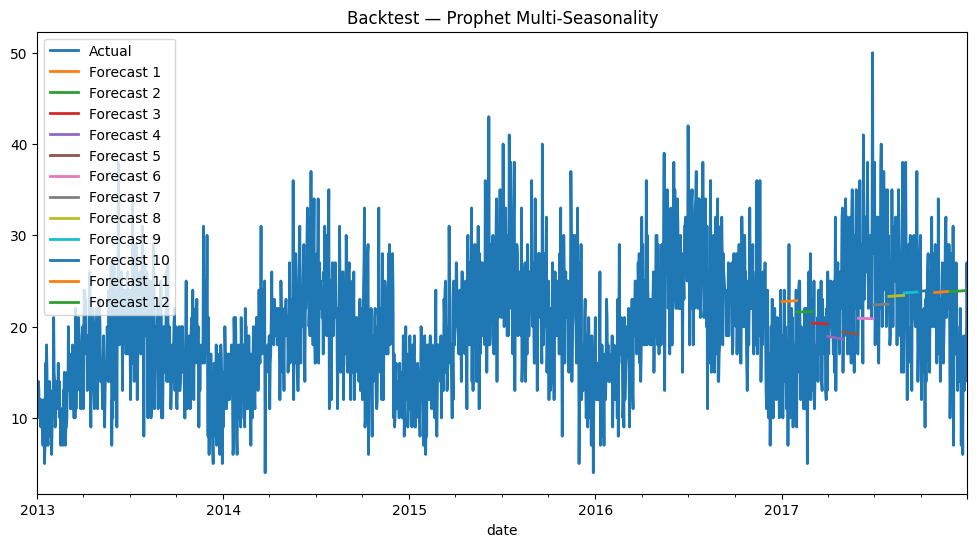

MAPE = 32.13%


In [59]:
# Параметри бектесту
hfc_params = {
    "series": series,
    "start": pd.Timestamp("2017-01-01"),
    "forecast_horizon": 30, 
    "retrain": True, 
}

# Бектест
historical_fcast = prophet_model_multi.historical_forecasts(
    last_points_only=False,
    stride=30,
    **hfc_params
)


series.plot(label="Actual")
for idx, hfc in enumerate(historical_fcast):
    hfc.plot(label=f"Forecast {idx+1}")
plt.title("Backtest — Prophet Multi-Seasonality")
plt.legend()
plt.show()


historical_fcast_concat = concatenate(historical_fcast, axis=0)
print(f"MAPE = {mape(series, historical_fcast_concat):.2f}%")

18:22:44 - cmdstanpy - INFO - Chain [1] start processing


Бектест з 2016-12-31 00:00:00 по 2017-12-31 00:00:00


18:22:44 - cmdstanpy - INFO - Chain [1] done processing
18:22:44 - cmdstanpy - INFO - Chain [1] start processing
18:22:44 - cmdstanpy - INFO - Chain [1] done processing
18:22:45 - cmdstanpy - INFO - Chain [1] start processing
18:22:45 - cmdstanpy - INFO - Chain [1] done processing
18:22:45 - cmdstanpy - INFO - Chain [1] start processing
18:22:45 - cmdstanpy - INFO - Chain [1] done processing
18:22:45 - cmdstanpy - INFO - Chain [1] start processing
18:22:45 - cmdstanpy - INFO - Chain [1] done processing
18:22:45 - cmdstanpy - INFO - Chain [1] start processing
18:22:45 - cmdstanpy - INFO - Chain [1] done processing
18:22:46 - cmdstanpy - INFO - Chain [1] start processing
18:22:46 - cmdstanpy - INFO - Chain [1] done processing
18:22:46 - cmdstanpy - INFO - Chain [1] start processing
18:22:46 - cmdstanpy - INFO - Chain [1] done processing
18:22:46 - cmdstanpy - INFO - Chain [1] start processing
18:22:47 - cmdstanpy - INFO - Chain [1] done processing
18:22:47 - cmdstanpy - INFO - Chain [1] 

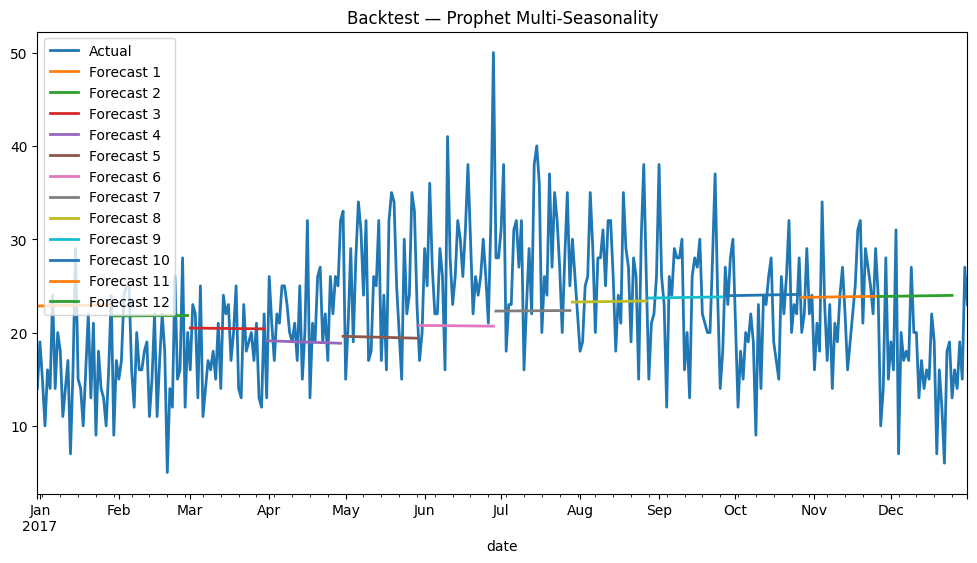

MAPE = 32.27%


In [ ]:
# Коректний старт — рівно 1 рік до кінця
start = series.end_time() - pd.DateOffset(years=1)
print(f"Бектест з {start} по {series.end_time()}")

hfc_params = {
    "series": series,
    "start": start,
    "forecast_horizon": 30,
}

historical_fcast = prophet_model_multi.historical_forecasts(
    last_points_only=False,
    stride=30,
    **hfc_params
)

# Візуалізація — тільки останній рік
series.slice(start, series.end_time()).plot(label="Actual")
for idx, hfc in enumerate(historical_fcast):
    hfc.plot(label=f"Forecast {idx+1}")

plt.title("Backtest — Prophet Multi-Seasonality")
plt.show()

historical_fcast_concat = concatenate(historical_fcast, axis=0)
print(f"MAPE = {mape(series, historical_fcast_concat):.2f}%")

| Model | MAPE |
|-------|------|
| Naive Seasonal | 38.17% |
| Naive Seasonal & Drift | 39.91% |
| Naive Seasonal & Drift with two seasonal components | 136.71% |
| Naive Seasonal & Drift with two weighted seasonal components | 26.28% |
| XGBoost Basic | 28.82% |
| XGBoost Past covariates | 24.48% |
| Exponential Smoothing Basic | 39.01% |
| Exponential Smoothing | 39.0% |
| ARIMA | 39.03% |
| SARIMAX | 25.3% |
| AutoARIMA | 39.49% |
| AutoARIMA Season | 35.1% |
| Prophet | 23.8% |
| **Prophet multi** | **22.97%** |
| RNN | 27.67% |

The best accuracy was obtained in the case of the Prophet model with seasonal components, and a backtest was conducted for it accordingly.

The internal dynamics within specific months were not taken into account, but the model captured the general trend. At the same time, compared to runs on the entire validation set, in the current backtest we have a higher level of error.

### Next steps

In the case of forecasting sales for the next month for each of 50 items in each of 10 stores, two modeling strategies can be considered:
- current -- modeling each individual product and store, for which I would use Prophet, which takes into account the peculiarities of the time series well, which is important, since the previous analysis determined that some stores and products have quite significant volatility;
- modeling all combinations of products and stores simultaneously, while it might be worth considering the XGBoost model, which also showed quite good results, and it learns much faster compared to Prophet.